# Plotting the distribution of z-scores of CCFs for clonal mutations

# Set up

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Define the colors from colorbrewer2
orange1 = '#feedde'
orange2 = '#fdbe85'
orange3 = '#fd8d3c'
orange4 = '#e6550d'
orange5 = '#a63603'
blue1 = '#eff3ff'
blue2 = '#bdd7e7'
blue3 = '#6baed6'
blue4 = '#3182bd'
blue5 = '#08519c'
green1 = '#edf8e9'
green2 = '#bae4b3'
green3 = '#74c476'
green4 = '#31a354'
green5 = '#006d2c'
grey1 = '#f7f7f7'
grey2 = '#cccccc'
grey3 = '#969696'
grey4 = '#636363'
grey5 = '#252525'
purple1 = '#f2f0f7'
purple2 = '#cbc9e2'
purple3 = '#9e9ac8'
purple4 = '#756bb1'
purple5 = '#54278f'
red1 = '#fee5d9'
red2 = '#fcae91'
red3 = '#fb6a4a'
red4 = '#de2d26'
red5 = '#a50f15'

# Load data

In [6]:
data = pd.read_parquet("../data/20260307_tracked_mutations_primary_and_met_data_eclipse_annotated.parquet")

In [11]:
print(data.head())

                Pos Error_mode   Depth  A     C     G  T   N  Alt   REF  ...  \
0  10:105147056:C:T       C->T  2896.0  0  2850     0  1  45  1.0  2850  ...   
1  10:121295943:C:T       C->T  3286.0  0  3259     0  0  27  0.0  3259  ...   
2   10:20023015:G:T       G->T  2770.0  0     0  2761  2   7  2.0  2761  ...   
3   10:28905355:C:T       C->T  1817.0  0  1810     0  1   6  1.0  1810  ...   
4   10:62648397:G:A       G->A  3117.0  1     0  3108  0   8  1.0  3108  ...   

  clone_purity clone_purity_UpCI  clone_purity_LwCI  clone_present_p  \
0          NaN               NaN                NaN    1.948062e-257   
1          NaN               NaN                NaN    1.948062e-257   
2          NaN               NaN                NaN    1.948062e-257   
3          NaN               NaN                NaN    1.948062e-257   
4          NaN               NaN                NaN    1.948062e-257   

           mrd_p mutation_present_p power_clone_ccf  power_sample_ccf  \
0  1.948062e-

In [12]:
# Check what zscore looks like
print(data['zscore'].describe())
print(data['zscore'].isna().sum())  # how many are NaN?


count    3.112360e+05
mean     1.083484e-17
std      9.643442e-01
min     -3.978467e+00
25%     -4.962126e-01
50%     -1.759531e-01
75%      2.189760e-01
max      1.869992e+01
Name: zscore, dtype: float64
571520


In [13]:
print(data['Pos'].nunique())

136553


In [14]:
mutation_counts = data['Pos'].value_counts()
print(mutation_counts.describe())

count    136553.000000
mean          6.464567
std           4.032655
min           1.000000
25%           3.000000
50%           6.000000
75%          10.000000
max         208.000000
Name: count, dtype: float64


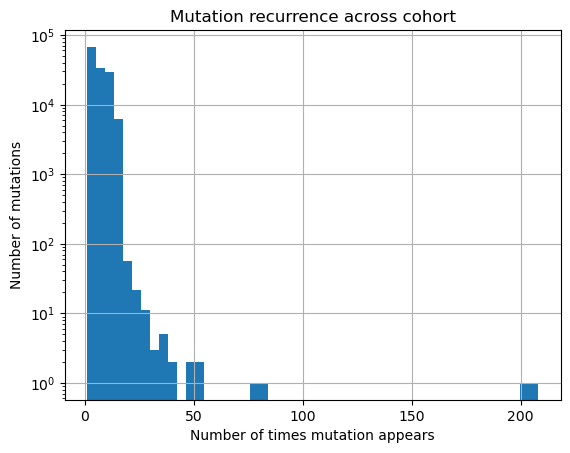

In [17]:
# Distribution of how many times each mutation appears
import matplotlib.pyplot as plt

mutation_counts.hist(bins=50)
plt.xlabel('Number of times mutation appears')
plt.ylabel('Number of mutations')
plt.title('Mutation recurrence across cohort')
plt.yscale('log')
plt.show()

In [18]:
print(data['ccf'].describe())

count    326507.000000
mean          1.868564
std         250.538514
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max      132246.858065
Name: ccf, dtype: float64


In [19]:
print(data['ccf'].isna().sum())

556249


In [21]:
print(data['ccf'].value_counts())

ccf
0.000000     250725
0.936677          2
0.505406          2
2.361807          2
1.011109          2
              ...  
1.186289          1
1.092400          1
2.892886          1
1.090402          1
53.024843         1
Name: count, Length: 75728, dtype: int64


In [20]:
print(data['is_subclonal_sample'].value_counts())

is_subclonal_sample
False    238414
True      88634
Name: count, dtype: int64


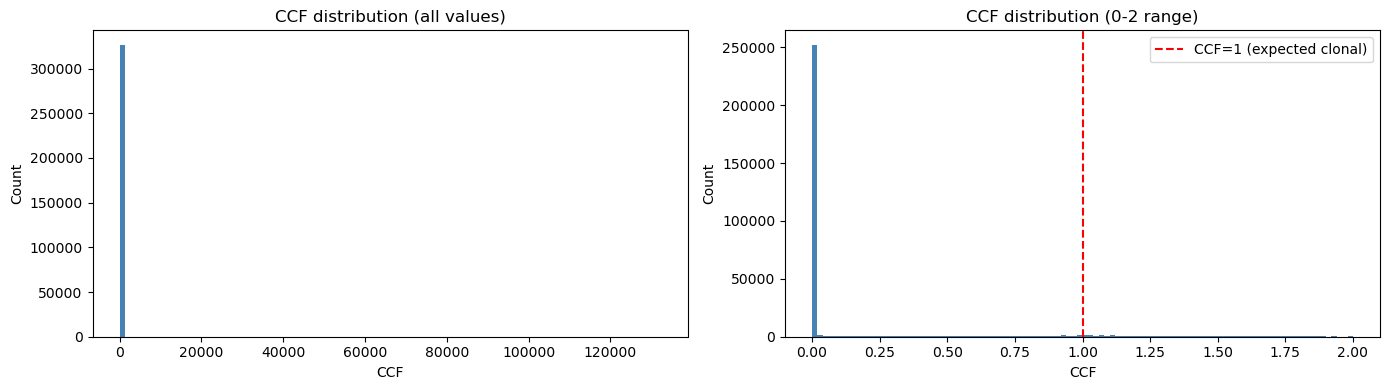

count    326507.000000
mean          1.868564
std         250.538514
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max      132246.858065
Name: ccf, dtype: float64
Values > 1: 37267
Values > 2: 10510


In [ ]:
# Remove NaNs first
ccf_clean = data['ccf'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Full distribution
axes[0].hist(ccf_clean, bins=100, edgecolor='none', color='steelblue')
axes[0].set_xlabel('CCF')
axes[0].set_ylabel('Count')
axes[0].set_title('CCF distribution (all values)')

# Zoomed in to 0-2 (most biologically meaningful range)
ccf_zoom = ccf_clean[ccf_clean <= 2]
axes[1].hist(ccf_zoom, bins=100, edgecolor='none', color='steelblue')
axes[1].set_xlabel('CCF')
axes[1].set_ylabel('Count')
axes[1].set_title('CCF distribution (0-2 range)')
axes[1].axvline(x=1, color='red', linestyle='--', label='CCF=1 (expected clonal)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(ccf_clean.describe())
print(f"Values > 1: {(ccf_clean > 1).sum()}")
print(f"Values > 2: {(ccf_clean > 2).sum()}")

In [24]:
print(data['clone_ccf'].describe())

count    327048.000000
mean          0.482260
std           0.478350
min           0.000000
25%           0.000000
50%           0.310887
75%           0.999487
max           1.000000
Name: clone_ccf, dtype: float64


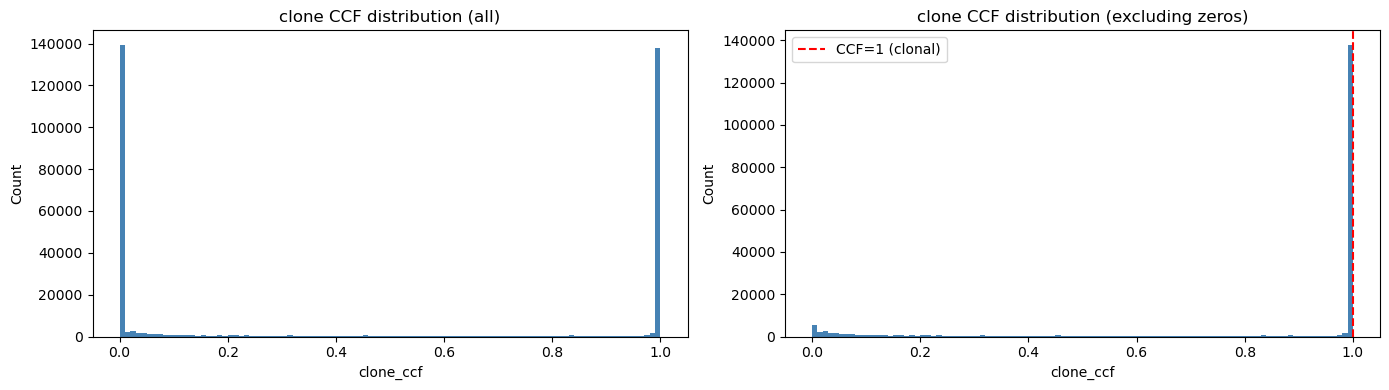

Zero values: 133969
Near 1 (>0.9): 142549
Subclonal (0.1-0.9): 31925


In [25]:
# Visualise clone_ccf
clone_ccf_clean = data['clone_ccf'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Full distribution
axes[0].hist(clone_ccf_clean, bins=100, edgecolor='none', color='steelblue')
axes[0].set_xlabel('clone_ccf')
axes[0].set_ylabel('Count')
axes[0].set_title('clone CCF distribution (all)')

# Exclude zeros to see the detected distribution better
clone_ccf_nonzero = clone_ccf_clean[clone_ccf_clean > 0]
axes[1].hist(clone_ccf_nonzero, bins=100, edgecolor='none', color='steelblue')
axes[1].axvline(x=1, color='red', linestyle='--', label='CCF=1 (clonal)')
axes[1].set_xlabel('clone_ccf')
axes[1].set_ylabel('Count')
axes[1].set_title('clone CCF distribution (excluding zeros)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Zero values: {(clone_ccf_clean == 0).sum()}")
print(f"Near 1 (>0.9): {(clone_ccf_clean > 0.9).sum()}")
print(f"Subclonal (0.1-0.9): {((clone_ccf_clean > 0.1) & (clone_ccf_clean < 0.9)).sum()}")

# Process data

In [ ]:
# Keep only data from ctDNA positive samples
